In [1]:
# ==========================================
# Plant Disease Detection using MobileNetV2
# Week 7 - Makers Conclave
# ==========================================

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [2]:
# ==========================================
# Configuration
# ==========================================

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 10

LEARNING_RATE = 0.0001

DATASET_PATH = "New Plant Diseases Dataset(Augmented)"

In [3]:
print(os.listdir(DATASET_PATH))

['train', 'valid']


In [4]:
train_path = os.path.join(DATASET_PATH, "train")
valid_path = os.path.join(DATASET_PATH, "valid")

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=25,

    zoom_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'

)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(IMAGE_SIZE, IMAGE_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical'

)

validation_generator = valid_datagen.flow_from_directory(

    valid_path,

    target_size=(IMAGE_SIZE, IMAGE_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False

)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [5]:
class_names = train_generator.class_indices

print(class_names)

with open("class_names.json","w") as f:
    json.dump(class_names,f,indent=4)

print("\nClass names saved successfully.")

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

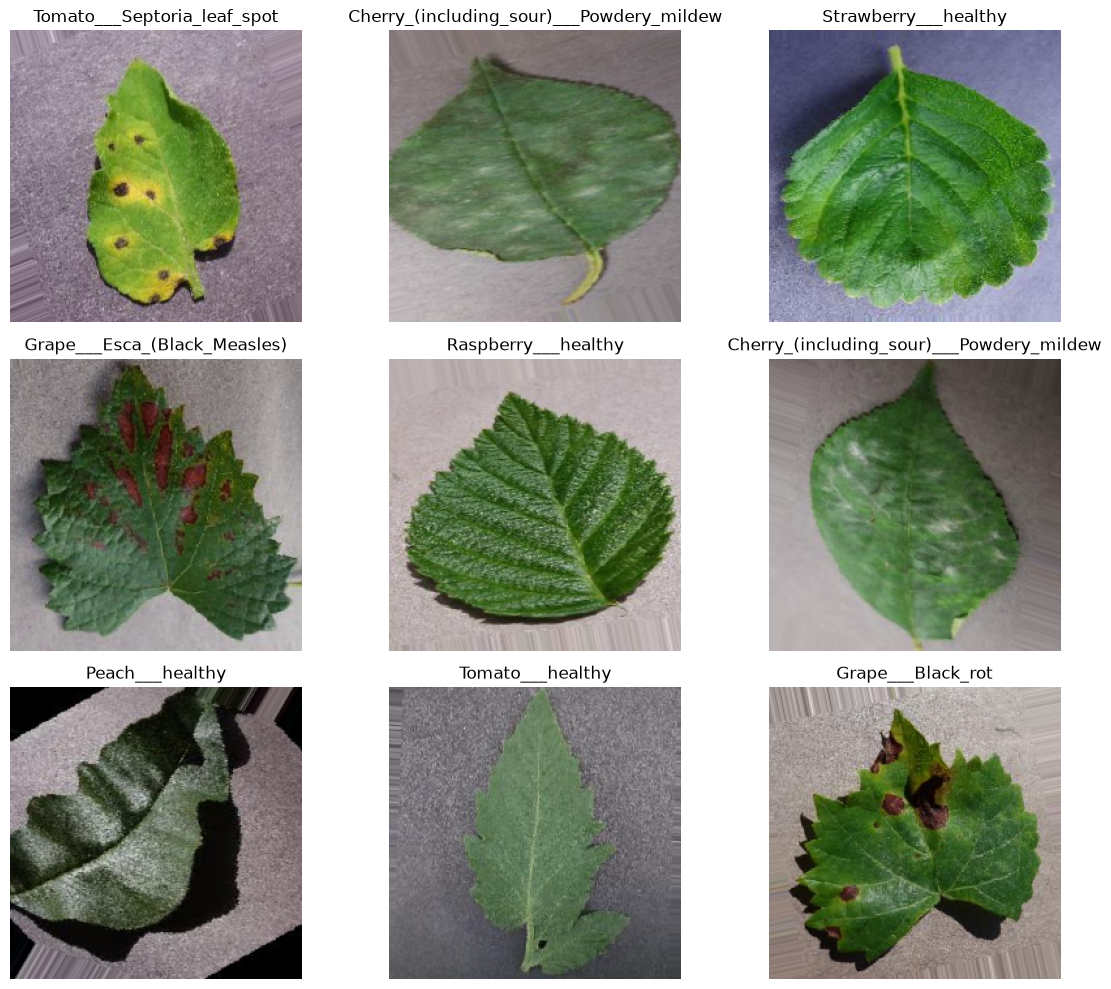

In [6]:
images, labels = next(train_generator)

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(list(class_names.keys())[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ==========================================
# Load MobileNetV2
# ==========================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

print("Base Model Loaded Successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base Model Loaded Successfully!


In [8]:
# ==========================================
# Custom Classification Head
# ==========================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,060,070 (11.67 MB)

 Trainable params: 799,526 (3.05 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
# ==========================================
# Compile Model
# ==========================================

model.compile(

    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),

    loss='categorical_crossentropy',

    metrics=[
        'accuracy'
    ]

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [11]:
# ==========================================
# Training Callbacks
# ==========================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=2,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_disease_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1

)

In [12]:
# ==========================================
# Train the Model
# ==========================================

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6220 - loss: 1.3280
Epoch 1: val_accuracy improved from None to 0.88243, saving model to best_disease_model.keras

Epoch 1: finished saving model to best_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1002s 455ms/step - accuracy: 0.6220 - loss: 1.3280 - val_accuracy: 0.8824 - val_loss: 0.3675 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.8215 - loss: 0.5668
Epoch 2: val_accuracy improved from 0.88243 to 0.92084, saving model to best_disease_model.keras

Epoch 2: finished saving model to best_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 985s 448ms/step - accuracy: 0.8215 - loss: 0.5668 - val_accuracy: 0.9208 - val_loss: 0.2502 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8624 - loss: 0.4334
Epoch 3: val_accuracy improved from 0.92084 to 0.93069, saving model to best_disease_model.keras

Epoch 3: finished 

In [13]:
model.save("disease_model.keras")

# Optional (legacy format)
model.save("disease_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


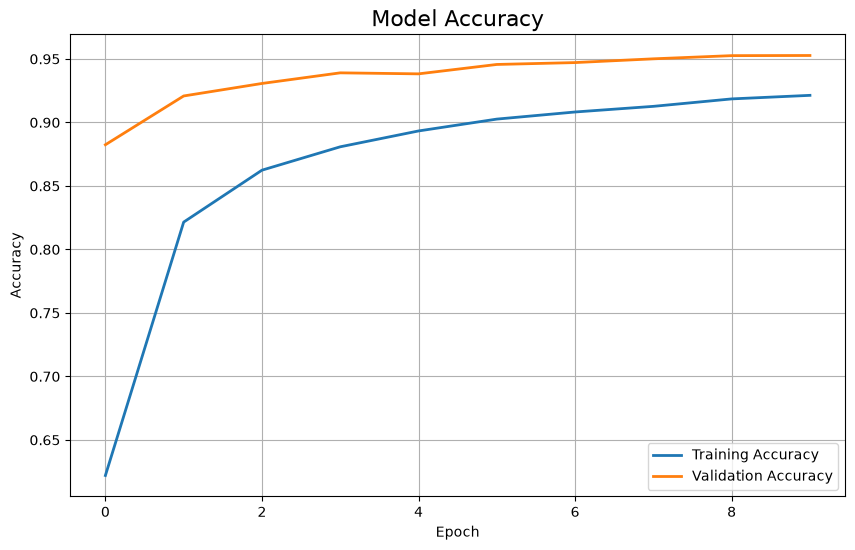

In [14]:
# ==========================================
# Training & Validation Accuracy
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title("Model Accuracy", fontsize=16)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

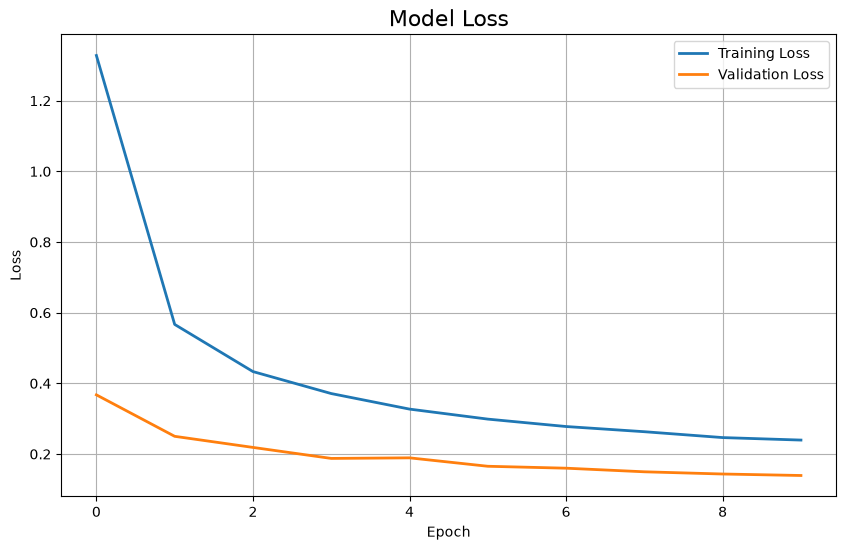

In [15]:
# ==========================================
# Training & Validation Loss
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title("Model Loss", fontsize=16)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
# ==========================================
# Model Evaluation
# ==========================================

loss, accuracy = model.evaluate(validation_generator)

print("\nValidation Loss :", round(loss,4))

print("Validation Accuracy :", round(accuracy*100,2),"%")

550/550 ━━━━━━━━━━━━━━━━━━━━ 144s 262ms/step - accuracy: 0.9527 - loss: 0.1393

Validation Loss : 0.1393
Validation Accuracy : 95.27 %


In [17]:
# ==========================================
# Predict Validation Images
# ==========================================

validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

550/550 ━━━━━━━━━━━━━━━━━━━━ 146s 264ms/step


In [18]:
# ==========================================
# Precision, Recall & F1 Score
# ==========================================

from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.94      0.96       504
                                 Apple___Black_rot       0.97      0.99      0.98       497
                          Apple___Cedar_apple_rust       1.00      0.98      0.99       440
                                   Apple___healthy       0.98      0.98      0.98       502
                               Blueberry___healthy       1.00      0.97      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       421
                 Cherry_(including_sour)___healthy       0.95      0.99      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.85      0.90       410
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.97      0.

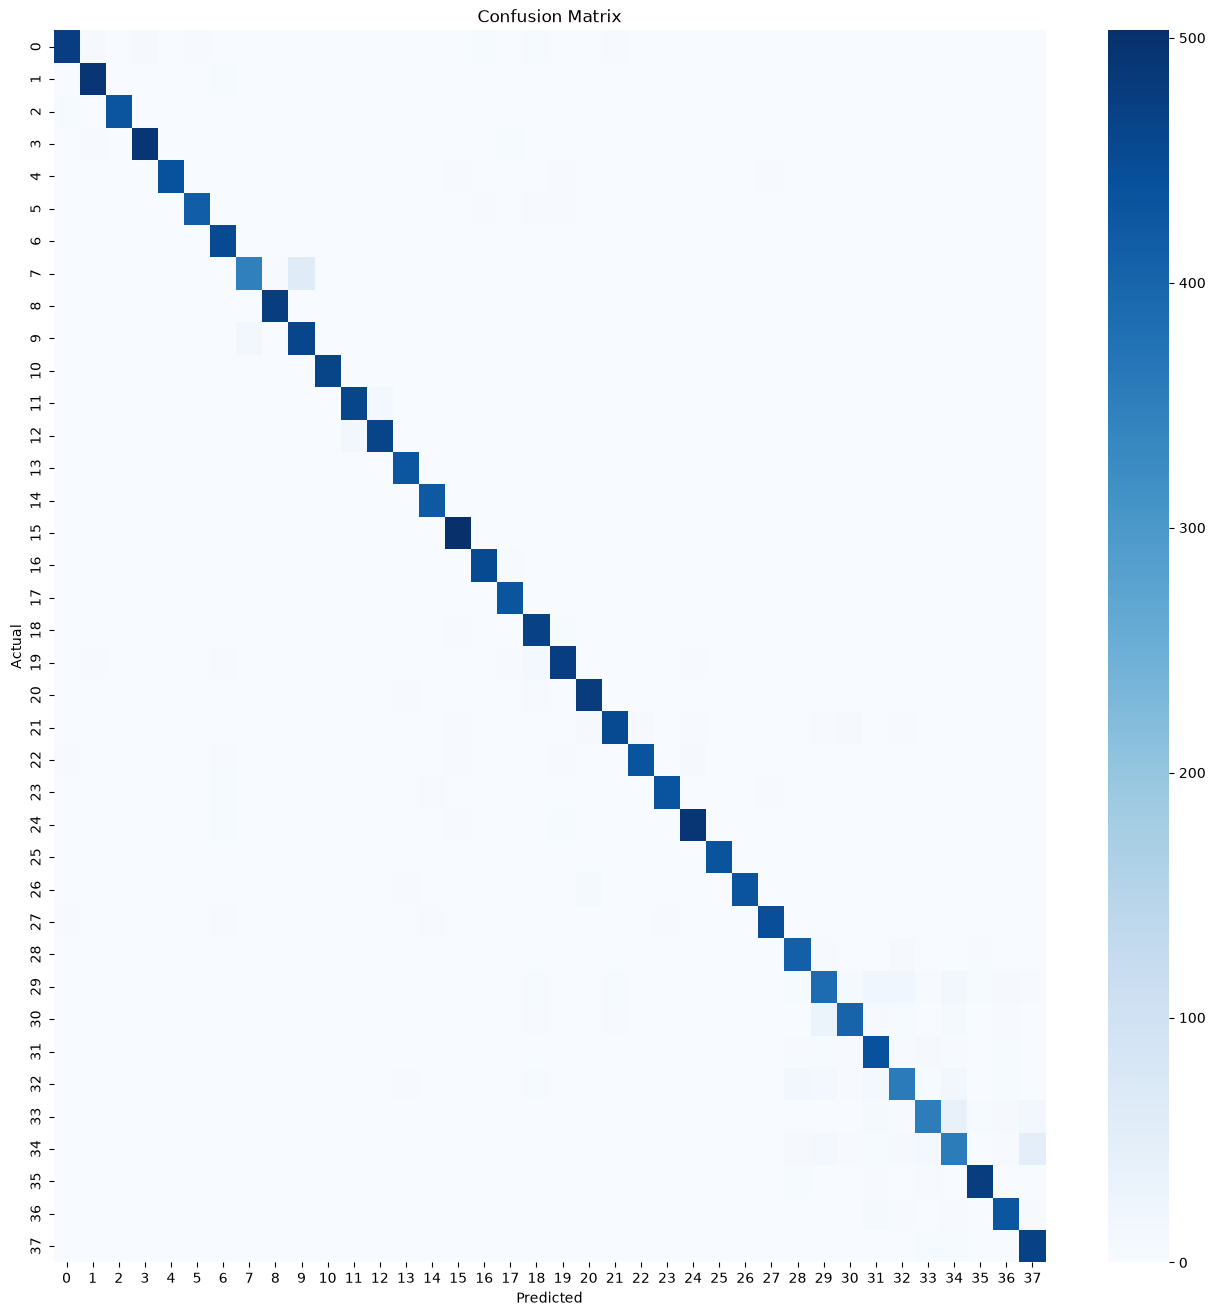

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(16,16))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=False
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [20]:
plt.figure(figsize=(16,16))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=False
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.close()

In [21]:
plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend([
    "Training",
    "Validation"
])

plt.grid(True)

plt.savefig(
    "accuracy_graph.png",
    dpi=300
)

plt.close()

In [22]:
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend([
    "Training",
    "Validation"
])

plt.grid(True)

plt.savefig(
    "loss_graph.png",
    dpi=300
)

plt.close()

In [23]:
from tensorflow.keras.preprocessing import image

image_path = "test_images/leaf1.jpg"

img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array/255

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

confidence = np.max(prediction)

predicted_label = class_labels[predicted_index]

print("Prediction :", predicted_label)

print("Confidence :", round(confidence*100,2),"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
Prediction : Tomato___Late_blight
Confidence : 43.95 %


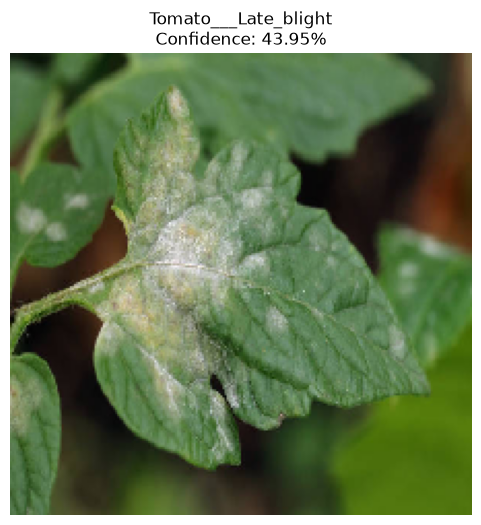

In [24]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f"{predicted_label}\nConfidence: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()

In [25]:
model.save("Plant_Disease_Detection_Model.keras")

model.save("Plant_Disease_Detection_Model.h5")

print("Final Model Saved Successfully.")

Final Model Saved Successfully.


week 8


In [4]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
model = load_model("best_disease_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [6]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

DATASET_PATH = "New Plant Diseases Dataset(Augmented)"

In [7]:
valid_path = os.path.join(DATASET_PATH, "valid")

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 17572 images belonging to 38 classes.


In [8]:
validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

550/550 ━━━━━━━━━━━━━━━━━━━━ 144s 260ms/step


In [9]:
accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average="weighted")
recall = recall_score(true_classes, predicted_classes, average="weighted")
f1 = f1_score(true_classes, predicted_classes, average="weighted")

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

Accuracy : 95.27%
Precision : 95.31%
Recall : 95.27%
F1 Score : 95.24%


In [10]:
# ==========================================
# Prediction Confidence Threshold
# ==========================================

CONFIDENCE_THRESHOLD = 0.80

print(f"Confidence Threshold = {CONFIDENCE_THRESHOLD*100}%")

Confidence Threshold = 80.0%


In [11]:
# ==========================================
# Smart Prediction Function
# ==========================================

def predict_disease(img_array):

    prediction = model.predict(img_array, verbose=0)

    confidence = np.max(prediction)

    predicted_class = np.argmax(prediction)

    class_names = list(validation_generator.class_indices.keys())

    if confidence < CONFIDENCE_THRESHOLD:

        return {
            "Prediction": "Unknown Disease",
            "Confidence": confidence
        }

    return {
        "Prediction": class_names[predicted_class],
        "Confidence": confidence
    }

In [16]:
from tensorflow.keras.preprocessing import image

image_path = "test_images/leaf1.jpg"

img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255

img_array = np.expand_dims(img_array, axis=0)

result = predict_disease(img_array)

print(result)

{'Prediction': 'Unknown Disease', 'Confidence': np.float32(0.43948662)}


In [14]:
import matplotlib.pyplot as plt

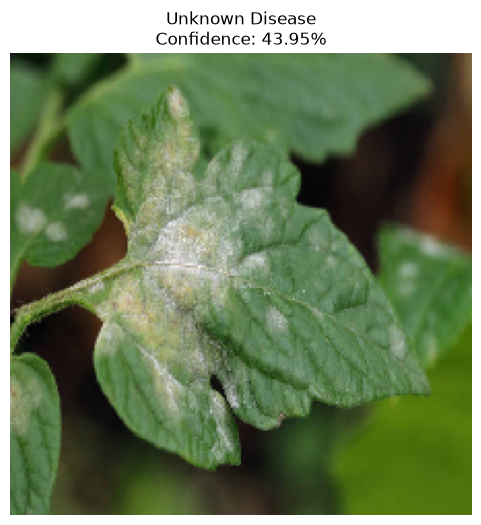

In [15]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f"{result['Prediction']}\nConfidence: {result['Confidence']*100:.2f}%"
)

plt.axis("off")

plt.show()

In [17]:
prediction_report = pd.DataFrame({

    "Image":[image_path],

    "Prediction":[result["Prediction"]],

    "Confidence":[round(result["Confidence"]*100,2)]

})

prediction_report

,Image,Prediction,Confidence
0,test_images/leaf1.jpg,Unknown Disease,43.950001


In [18]:
prediction_report.to_csv(
    "prediction_report.csv",
    index=False
)

print("Prediction report saved successfully.")

Prediction report saved successfully.


In [19]:
import time

In [20]:
NUM_RUNS = 100

start = time.time()

for _ in range(NUM_RUNS):

    model.predict(
        img_array,
        verbose=0
    )

end = time.time()

average_time = (end - start) / NUM_RUNS

print(f"Average Prediction Time: {average_time:.4f} seconds")

print(f"Average Prediction Time: {average_time*1000:.2f} ms")

Average Prediction Time: 0.0631 seconds
Average Prediction Time: 63.10 ms


In [21]:
benchmark = pd.DataFrame({

    "Runs":[NUM_RUNS],

    "Average Time (seconds)":[average_time],

    "Average Time (ms)":[average_time*1000]

})

benchmark.to_csv(
    "benchmark_results.csv",
    index=False
)

benchmark

,Runs,Average Time (seconds),Average Time (ms)
0,100,0.063103,63.10312


In [22]:
import os
import shutil

deployment_dir = "deployment"

os.makedirs(deployment_dir, exist_ok=True)

print("Deployment folder created successfully!")

Deployment folder created successfully!


In [23]:
files_to_copy = [
    "best_disease_model.keras",
    "Plant_Disease_Detection_Model.keras",
    "class_names.json",
    "accuracy_graph.png",
    "loss_graph.png",
    "confusion_matrix.png"
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, deployment_dir)
        print(f"Copied: {file}")
    else:
        print(f"File not found: {file}")

Copied: best_disease_model.keras
Copied: Plant_Disease_Detection_Model.keras
Copied: class_names.json
Copied: accuracy_graph.png
Copied: loss_graph.png
Copied: confusion_matrix.png


In [25]:
with open("deployment/model_summary.txt", "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary exported successfully!")

Model summary exported successfully!


In [26]:
performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

performance.to_csv(
    "deployment/model_performance.csv",
    index=False
)

performance

,Metric,Value
0,Accuracy,0.952709
1,Precision,0.953090
2,Recall,0.952709
3,F1 Score,0.952383


In [27]:
readme = f"""
# Plant Disease Detection Model

## Model

MobileNetV2 Transfer Learning

## Dataset

PlantVillage Dataset

## Image Size

224 x 224

## Batch Size

32

## Epochs

10

## Optimizer

Adam

## Learning Rate

0.0001

## Performance

Accuracy : {accuracy*100:.2f} %

Precision : {precision*100:.2f} %

Recall : {recall*100:.2f} %

F1 Score : {f1*100:.2f} %

## Output Files

best_disease_model.keras

Plant_Disease_Detection_Model.keras

class_names.json

accuracy_graph.png

loss_graph.png

confusion_matrix.png

model_summary.txt

model_performance.csv

benchmark_results.csv
"""

with open("deployment/README.md", "w") as f:
    f.write(readme)

print("README generated successfully!")

README generated successfully!


In [28]:
print("Deployment Package:\n")

for file in os.listdir("deployment"):
    print(file)

Deployment Package:

accuracy_graph.png
best_disease_model.keras
class_names.json
confusion_matrix.png
loss_graph.png
model_performance.csv
model_summary.txt
Plant_Disease_Detection_Model.keras
README.md


In [29]:
import shutil

shutil.make_archive(
    "Plant_Disease_Deployment",
    "zip",
    "deployment"
)

print("Deployment ZIP created successfully!")

Deployment ZIP created successfully!
